In [1]:
import os
import cv2
import gdown
import torch
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, Tuple
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import wandb
from IPython.display import clear_output
from PIL import Image
from sklearn.metrics import (
    RocCurveDisplay,
    auc,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from tqdm.notebook import tqdm, trange

import optuna
from optuna.samplers import TPESampler


# url = "https://drive.google.com/uc?id=1DHuQ3DBsgab6NtZIZfAKUHS2rW3-vmtb"
# output = "dataset"
# gdown.download(url, output, quiet=False)

# file_id = '1DHuQ3DBsgab6NtZIZfAKUHS2rW3-vmtb'
# gdown.download(f'https://drive.google.com/uc?id={file_id}', 'myfile.zip', quiet=False)
# zip_path = 'myfile.zip'
# extract_path = './extracted_files/'

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print(f"Файл распакован в: {extract_path}")

In [2]:
cd image_itmo_course

/mnt/hot/aihub/rgurtsiev/image_itmo_course


/mnt/hot/aihub/rgurtsiev/miniconda3/envs/myenv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Create Dataset and DataLoader

In [3]:
class ImageProcessor:
    def __init__(self, image_shape=None):
        self.image_shape = image_shape

    def compute_common_size(self, images_dir, image_ids):
        shapes = []
        for image_id in image_ids:
            image_path = os.path.join(images_dir, image_id)
            image = cv2.imread(image_path)
            shapes.append(image.shape)
        shapes = np.array(shapes)
        common_height = int(np.quantile(shapes[:, 0], 0.99))
        common_width = int(np.quantile(shapes[:, 1], 0.99))
        return common_height, common_width

    def resize(self, image):
        if not self.image_shape:
            raise ValueError("Image shape not set for resizing.")
        common_height, common_width = self.image_shape
        return cv2.resize(image, (common_width, common_height))

    def normalize(self, image):
        return cv2.normalize(image, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    def to_tensor(self, image):
        tensor_image = torch.tensor(image, dtype=torch.float32)
        return tensor_image.permute(2, 0, 1) 


class LabelLoader:
    @staticmethod
    def load_labels(labels_path):
        labels = {}
        if os.path.exists(labels_path):
            with open(labels_path) as f:
                lines = f.readlines()
            for line in lines:
                path, label = line.split()
                labels[path] = int(label)
        return labels


class CustomDataset(Dataset):
    def __init__(self, split="train", dataset_dir="dataset", image_shape=None, transforms=None):
        self.dataset_dir = dataset_dir
        self.split = split
        self.root_dir = os.path.join(self.dataset_dir, self.split)
        self.transforms = transforms
        
        self.images_dir = os.path.join(self.root_dir, "imgs" if split == "test" else "")
        self.image_ids = [
            fname for fname in os.listdir(self.images_dir) if fname.endswith(".jpg")
        ]

        self.labels = LabelLoader.load_labels(
            os.path.join(self.root_dir, "test_annotation.txt")
        )

        self.processor = ImageProcessor(image_shape)
        if not image_shape:
            self.processor.image_shape = self.processor.compute_common_size(
                self.images_dir, self.image_ids
            )

    @property
    def image_shape(self):
        return self.processor.image_shape

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.images_dir, image_id)
        image = cv2.imread(image_path)

        image = self.processor.normalize(image)
        image = self.processor.resize(image)
        image = self.processor.to_tensor(image)

        if self.transforms:
            image = self.transforms(image)

        label = self.labels.get(image_id, 0)
        return image, label

In [4]:
# Создадим datset и dataloader

RANDOM_SEED = 0
SPLIT_RATIO = 0.05
BATCH_SIZE = 128
PROJECT = "hw_2"
np.random.seed(RANDOM_SEED)

train_dataset = CustomDataset("train")
proliv_dataset = CustomDataset("proliv", image_shape=train_dataset.image_shape)
test_dataset = CustomDataset("test", image_shape=train_dataset.image_shape)

val_split = int(np.floor(SPLIT_RATIO * len(train_dataset)))
indices = list(range(len(train_dataset)))
np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)
train_sampler = SubsetRandomSampler(indices[val_split:])
val_sampler = SubsetRandomSampler(indices[:val_split])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(train_dataset, batch_size=1, sampler=val_sampler)

proliv_loader = DataLoader(proliv_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Визуализируем

In [5]:
def display(image: torch.Tensor):
    image = (image * 255).type(torch.int).transpose(0, 2)
    plt.imshow(image)
    
def visualize(model, batch):
    model.to("cpu")
    batch.to("cpu")
    display(batch[0])
    plt.show()
    model.eval()
    with torch.no_grad():
        output = model(batch)[0]
        display(output)
        loss = ((batch - output) ** 2).sum()
        print(f"Loss: {loss:.2f}")

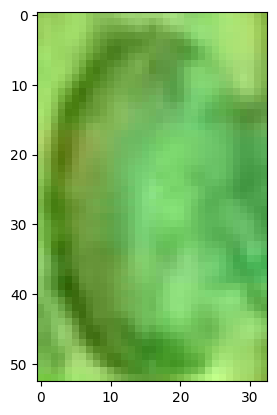

In [6]:
display(train_dataset[0][0])

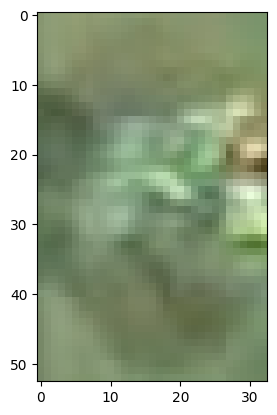

In [7]:
display(proliv_dataset[0][0])

# Model

In [8]:
# AE

class Encoder(nn.Module):
    def __init__(self, input_dims, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(input_dims, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)

class Decoder(nn.Module):
    def __init__(self, out_dims, latent_dims, shape):
        super(Decoder, self).__init__()
        self.shape = shape
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, out_dims)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, *self.shape))

class Autoencoder(nn.Module):
    def __init__(self, shape, latent_dims):
        super(Autoencoder, self).__init__()
        self.shape = shape
        self.latent_dims = latent_dims
        self.input_dims = torch.prod(torch.tensor(self.shape))
        self.encoder = Encoder(self.input_dims, self.latent_dims)
        self.decoder = Decoder(self.input_dims, self.latent_dims, self.shape)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# VAE
class VariationalEncoder(nn.Module):
    def __init__(self, input_dims, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(input_dims, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.to(device) 
        self.N.scale = self.N.scale.to(device)
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1 / 2).sum()
        return z

class VariationalAutoencoder(nn.Module):
    def __init__(self, shape, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.shape = shape
        self.latent_dims = latent_dims
        self.input_dims = torch.prod(torch.tensor(self.shape))
        self.encoder = VariationalEncoder(self.input_dims, self.latent_dims)
        self.decoder = Decoder(self.input_dims, self.latent_dims, self.shape)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [9]:
device = 'cuda'

latent_dims = 2
shape = next(iter(train_loader))[0].shape
autoencoder = Autoencoder(shape[1:], latent_dims)
vae = VariationalAutoencoder(shape[1:], latent_dims).to(device)

# Metrics

In [10]:
def compute_metrics(y_true, losses, th):
    y_pred = [1 if loss > th else 0 for loss in losses]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    roc_auc = roc_auc_score(y_true, y_pred)
    return tpr, tnr, roc_auc

def det_threshold(model, val_loader, proliv_loader, plot=True):
    model.to(device)
    val_losses = eval(model, val_loader)
    proliv_losses = eval(model, proliv_loader)
    y_true = np.hstack((np.zeros(len(val_losses)), np.ones(len(proliv_losses))))
    losses = np.hstack((val_losses, proliv_losses))
    fpr, tpr, thresholds = roc_curve(np.array(y_true), losses)
    roc_auc = auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    if plot:
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot()
        plt.show()
    tpr, tnr, roc_auc = compute_metrics(y_true, losses, optimal_threshold)
    return optimal_threshold, tpr, tnr, roc_auc

def test_eval(model, data, y_true, th):
    losses = run_epoch(model, data, mode="eval")
    y_pred = [1 if loss > th else 0 for loss in losses]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    roc_auc = roc_auc_score(y_true, y_pred)
    return tpr, tnr, roc_auc

# Train

In [11]:
def run_epoch(model, data, mode="train", opt=None, show_pb=True):
    epoch_losses = []
    if show_pb:
        batches = tqdm(data)
    else:
        batches = data
    for x, y in batches:
        x = x.to(device)  # GPU
        if mode == "train":
            opt.zero_grad()
        x_hat = model(x)
        loss = ((x - x_hat) ** 2).sum() / data.batch_size
        epoch_losses.append(loss.item())
        if show_pb:
            batches.set_description(str(loss.item()))
        if mode == "train" and opt:
            loss.backward()
            opt.step()
    return epoch_losses


def train(
    model, data, lr=0.001, epochs=20, plot=True, pb_for_each_epoch=True, to_wandb=False
):
    model.to(device)
    model.train()
    loss_history = []
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    if not pb_for_each_epoch:
        epochs_range = trange(epochs)
    else:
        epochs_range = range(epochs)
    for epoch in epochs_range:
        if pb_for_each_epoch:
            print(f"Epoch: {epoch}")
        epoch_losses = run_epoch(
            model, data, mode="train", opt=opt, show_pb=pb_for_each_epoch
        )
        avg_epoch_loss = np.mean(epoch_losses)
        loss_history.append(avg_epoch_loss)
        if not pb_for_each_epoch:
            epochs_range.set_description(str(avg_epoch_loss))
        elif not plot:
            print(f"Train loss: {avg_epoch_loss}")

        if to_wandb:
            wandb.log({"loss": avg_epoch_loss})

        if plot:
            clear_output()
            print(f"Train loss: {avg_epoch_loss}")
            print("Loss curve")
            plt.plot(loss_history)
            plt.show()

    return model, loss_history


def eval(model, data):
    model.eval()
    losses = run_epoch(model, data, mode="eval")
    return losses

Train loss: 29.318175163269043
Loss curve


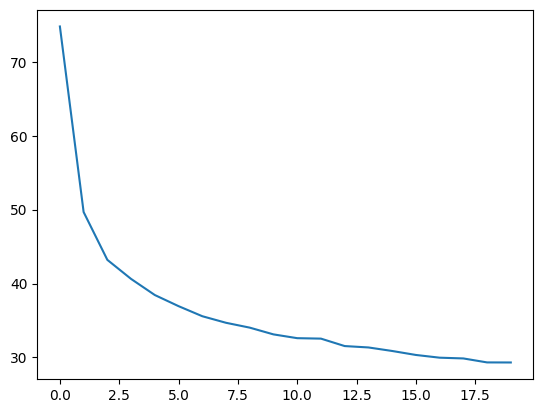

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

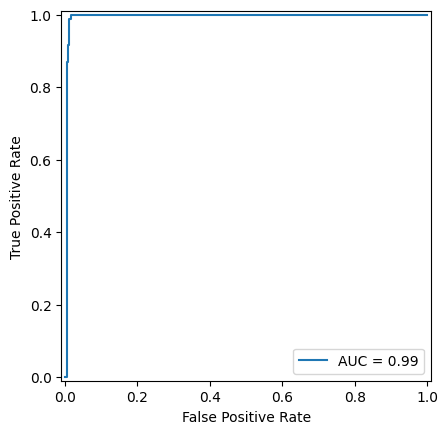

(np.float64(73.14202880859375),
 np.float64(0.987012987012987),
 np.float64(0.982),
 np.float64(0.9845064935064933))

In [12]:
autoencoder, loss_history = train(autoencoder, train_loader)
det_threshold(autoencoder, val_loader, proliv_loader)

# Подбор гиперпарметров

In [13]:
def parameters(trial):
    model = trial.suggest_categorical("model", ["AE", "VAE"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    epochs = trial.suggest_int("epochs", 10, 40)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    latent_dims = trial.suggest_categorical("latent_dims", [2, 4, 8, 16, 32, 64])

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler
    )
    shape = next(iter(train_loader))[0].shape
    if model == "AE":
        model = Autoencoder(shape[1:], latent_dims)
    elif model == "VAE":
        model = VariationalAutoencoder(shape[1:], latent_dims)
    model.to(device)

    wandb.init(project=PROJECT, config={**trial.params})
    model, loss_history = train(
        model,
        train_loader,
        lr=learning_rate,
        epochs=epochs,
        plot=False,
        pb_for_each_epoch=False,
        to_wandb=True,
    )
    th, val_tpr, val_tnr, val_roc_auc = det_threshold(
        model, val_loader, proliv_loader, plot=False
    )
    y_true = [int(b[1]) for b in list(test_loader)]
    tpr, tnr, roc_auc = test_eval(model, test_loader, y_true, th)
    wandb.log(
        {
            "val_tpr": val_tpr,
            "val_tnr": val_tnr,
            "val_roc_auc": val_roc_auc,
            "tpr": tpr,
            "tnr": tnr,
            "roc_auc": roc_auc,
        }
    )
    wandb.finish()
    return roc_auc

In [14]:
optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = TPESampler(seed=1)
study = optuna.create_study(
    study_name="proliv-deteсt", direction="maximize", sampler=sampler
)
study.optimize(parameters, n_trials=20)

[I 2025-01-11 22:35:07,746] A new study created in memory with name: proliv-deteсt
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: ilike528149 (r1char9). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/3794 [00:00<?, ?it/s]

...

  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/3794 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



loss,█▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
roc_auc,▁
tnr,▁
tpr,▁
val_roc_auc,▁
val_tnr,▁
val_tpr,▁
loss,17.54912
roc_auc,0.87792
tnr,0.94188
tpr,0.81395


[I 2025-01-11 22:45:48,344] Trial 19 finished with value: 0.8779180811573971 and parameters: {'model': 'AE', 'learning_rate': 2.6247569933901764e-05, 'epochs': 29, 'batch_size': 64, 'latent_dims': 32}. Best is trial 9 with value: 0.8996488890298973.


# Выделяем лучшие параметры

In [15]:
study.best_trial.params
_, learning_rate, epochs, batch_size, latent_dims = study.best_trial.params.values()

Train loss: 27.404186780020694
Loss curve


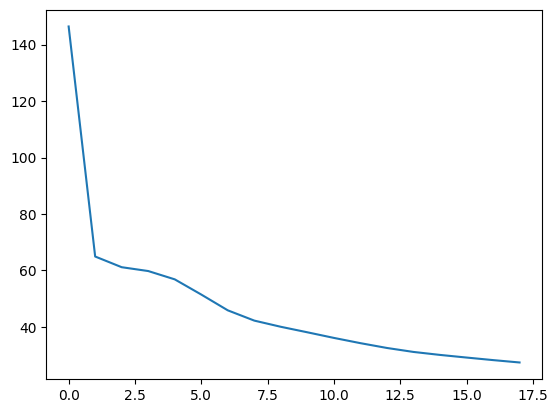

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

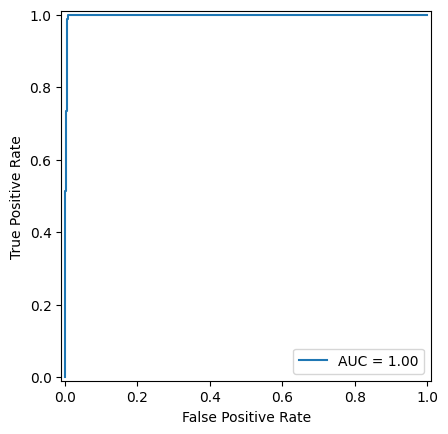

Evaluation on the test set ...


  0%|          | 0/3794 [00:00<?, ?it/s]

True Positive rate 0.853
True Neagtive rate: 0.926
ROC AUC score: 0.889


In [16]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
shape = next(iter(train_loader))[0].shape
model = VariationalAutoencoder(shape[1:], latent_dims)
model.to(device)

model, loss_history = train(model, train_loader, lr=learning_rate, epochs=epochs)

th, _, _, _ = det_threshold(model, val_loader, proliv_loader)

print("Evaluation on the test set ...")
y_true = [int(b[1]) for b in list(test_loader)]
tpr, tnr, roc_auc = test_eval(model, test_loader, y_true, th)
print(
    f"True Positive rate {tpr:.3f}\nTrue Neagtive rate: {tnr:.3f}\nROC AUC score: {roc_auc:.3f}"
)

# Результат

True Positive rate: 0.853    
True Neagtive rate: 0.926   
ROC AUC score: 0.899    